In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [ ]:
from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker
from src.utils.plotting import plot_markov_matrix
import matplotlib.pyplot as plt
import numpy as np
from src.utils.data_processing import downsample_block_mean, _make_edges_quantile_numba, _find_optimal_lattice_subset, generate_frequency_lattice

In [5]:
env = EnvConfig()
fleet_data = load_and_cache_entire_fleet(env)

Loading fleet data from binary cache (fleet_data_cache_scale_0.75.npz)...
 -> Cache instantly loaded in 0.087 seconds.


In [ ]:
exclude_days = [1,2,3]
train_days = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
delta_P = 90
for i in range(5, 6, 1):
    config = SimConfig(delta_P=delta_P, N_d=i, verbose=False)
    benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)
    mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
    plot_markov_matrix(mc_model, title=f"delta_P={delta_P}, N_d={i}")


In [ ]:
exclude_days = [1,2,3]
train_days = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
dP_range=range(500,49,-10)
N_d=3
for p in dP_range:
    config = SimConfig(delta_P=p, N_d=N_d, verbose=False)
    benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)
    mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
    plot_markov_matrix(mc_model, title=f"delta_P={p}, N_d={N_d}")


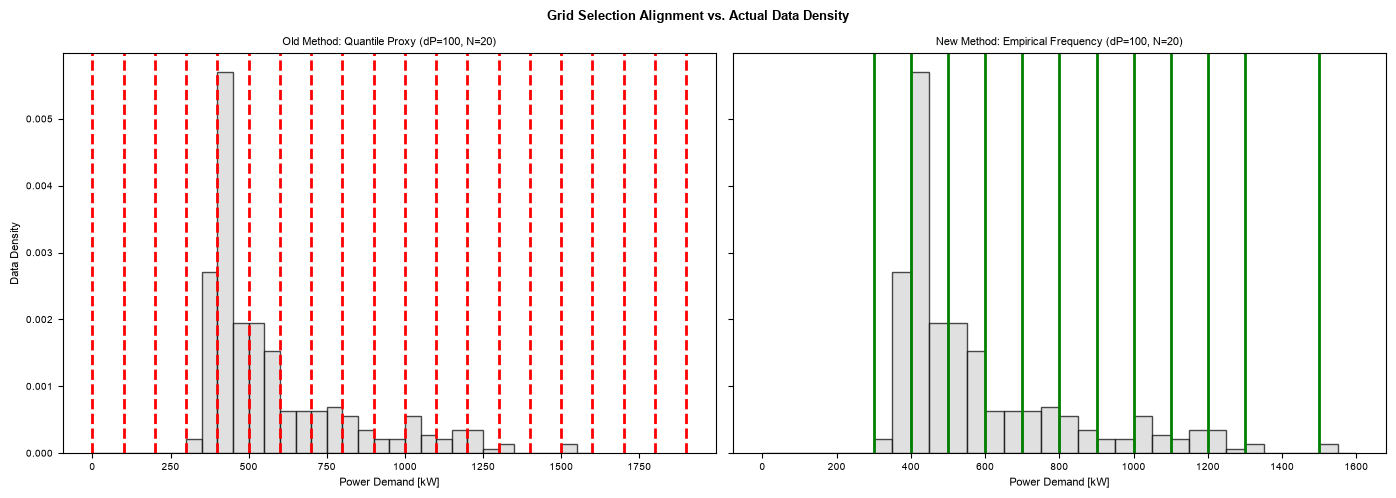

[ 300.  400.  500.  600.  700.  800.  900. 1000. 1100. 1200. 1300. 1500.]


In [23]:


def plot_grid_comparison(fleet_data, train_days, delta_P, N_d):
    # 1. Extract and format the raw training data
    train_t, train_pd = [], []
    for d in train_days:
        data = fleet_data[d]
        t_off = train_t[-1][-1] if train_t else 0.0
        train_t.append(data['t'] + t_off)
        train_pd.append(data['Pd'])
        
    t_concat = np.concatenate(train_t)
    pd_concat = np.concatenate(train_pd)
    ds_train = downsample_block_mean(t_concat, pd_concat, 300, align='t0')
    power_data = ds_train['Pd']
    max_val = power_data.max()

    # 2. OLD METHOD (Quantile Proxy)
    legacy_edges = _make_edges_quantile_numba(power_data, N_d)
    ideal_levels = np.array([(legacy_edges[i] + legacy_edges[i+1])/2.0 for i in range(N_d)])
    full_lattice = np.arange(0.0, max(max_val + delta_P, N_d * delta_P) + (delta_P / 2.0), delta_P)
    old_levels = _find_optimal_lattice_subset(ideal_levels, full_lattice)

    # 3. NEW METHOD (Frequency Projection)
    new_levels, _ = generate_frequency_lattice(power_data, delta_P, N_d)

    # 4. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    bins = np.arange(0, max_val + delta_P, delta_P/2)
    
    # Left Plot: Old Method
    axes[0].hist(power_data, bins=bins, color='lightgray', edgecolor='black', alpha=0.7, density=True)
    for lvl in old_levels:
        axes[0].axvline(lvl, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f"Old Method: Quantile Proxy (delta_P={delta_P}, N={N_d})")
    axes[0].set_xlabel("Power Demand [kW]")
    axes[0].set_ylabel("Data Density")

    # Right Plot: New Method
    axes[1].hist(power_data, bins=bins, color='lightgray', edgecolor='black', alpha=0.7, density=True)
    for lvl in new_levels:
        axes[1].axvline(lvl, color='green', linestyle='-', linewidth=2)
    axes[1].set_title(f"New Method: Empirical Frequency (delta_P={delta_P}, N={N_d})")
    axes[1].set_xlabel("Power Demand [kW]")

    plt.suptitle("Grid Selection Alignment vs. Actual Data Density", fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(new_levels)

# Run it!
plot_grid_comparison(fleet_data, train_days=[14], delta_P=100, N_d=20)